# Импорты

In [ ]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.1 MB/s eta 0:00:00


In [ ]:
import os

# os.environ['DDE_BACKEND'] = 'pytorch'
os.environ['DDE_BACKEND'] = 'tensorflow.compat.v1'

import deepxde as dde
print(f"DeepXDE backend: {dde.backend.backend_name}") # Должно напечатать используемый бэкенд (pytorch / 'tensorflow.compat.v1' / ...)

import torch
import tensorflow.compat.v1 as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.
Instructions for updating:
non-resource variables are not supported in the long term
Enable just-in-time compilation with XLA.



DeepXDE backend: tensorflow.compat.v1


In [ ]:
# Установка глобального сида
SEED = 42
dde.config.set_random_seed(SEED)

# Параметры

In [ ]:
# Константы материала
rho_cp = 4e6          # Дж/(м³·К)
k = 0.6               # Вт/(м·К)
alpha_absorption = 48.2      # 1/м
alpha = 1.5e-7
A = 0.4

T0 = 291.0          # начальная температура, K

# Геометрия
Lx = 40e-3
Ly = 10e-3
Lz = 5e-3   # глубина


# Параметры импульсов
r0 = 1e-3             # м
Ep = 0.1             # Дж
pulse_fwhm = 3.0      # с
pulse_sigma = pulse_fwhm / 2.355
t_peak = 3.0 * pulse_sigma
pulse_period = 20.0   # с
N_pulses = 3

# Время моделирования
T_end = 60.0

# Домен

In [ ]:
# Пространственная область
space = dde.geometry.Cuboid(xmin=[-Lx/2, -Ly/2, 0], xmax=[Lx/2, Ly/2, Lz])
timedomain = dde.geometry.TimeDomain(0, T_end)
geomtime = dde.geometry.GeometryXTime(space, timedomain)

# PDE

In [ ]:
# Пиковая плотность мощности (из энергии импульса)
Q0 = Ep / (np.pi * r0**2 * np.sqrt(2*np.pi) * pulse_sigma)

# Функция источника
def heat_source(x, y, z, t):
    """
    Возвращает Q(x,y,z,t)
    """
    # Поперечный множитель (FWHM)
    r2 = x**2 + y**2
    spatial = dde.backend.exp(-r2 * np.log(2) / r0**2)
    depth = alpha_absorption * dde.backend.exp(-alpha_absorption * z)

    Q_sum = 0.0
    for n in range(N_pulses):
        t_n = t_peak + n * pulse_period
        temp = dde.backend.exp(-(t - t_n)**2 / (2 * pulse_sigma**2))
        Q_sum += temp

    return A * Q0 * Q_sum * spatial * depth

In [ ]:
# Уравнение PDE
def pde(x, T):
    """
    x[:,0] = x, x[:,1] = y, x[:,2] = z, x[:,3] = t
    """
    T_t = dde.grad.jacobian(T, x, i=0, j=3)
    T_xx = dde.grad.hessian(T, x, i=0, j=0)
    T_yy = dde.grad.hessian(T, x, i=1, j=1)
    T_zz = dde.grad.hessian(T, x, i=2, j=2)
    Q_val = heat_source(x[:,0:1], x[:,1:2], x[:,2:3], x[:,3:4])
    return T_t - alpha * (T_xx + T_yy + T_zz) - Q_val / rho_cp # + k / Lx**2 * (T - T0)

# Граничные и начальные условия

In [ ]:
# Формируем данные для подачи в Loss

# Загружаем эталон
ref = np.loadtxt('out_Tt.txt', usecols=(0, 1, 2, 3)) # если не получилось прочитать, то можно попробовать добавить параметры: usecols=(0,1, 2, 3) ; delimiter=None
t_ref = ref[:, 0]           # время
T_ref_1mm = ref[:, 1]       # температура на z=1 мм

# Выбираем каждую 20-ю точку, чтобы получить ~50 точек с данными
step = max(1, len(t_ref) // 10) #
t_anchor = t_ref[::step]
T_anchor_val = T_ref_1mm[::step]

# Координаты точек: центр пучка x=0, y=0, глубина z=0.001 м
x_anchor = np.zeros_like(t_anchor)
y_anchor = np.zeros_like(t_anchor)
z_anchor = np.full_like(t_anchor, 0.001)  # 1 мм

# Формируем массивы для DeepXDE
X_anchor = np.stack([x_anchor, y_anchor, z_anchor, t_anchor], axis=-1)  # (N, 4)
T_anchor = T_anchor_val.reshape(-1, 1)

# Берем только более поздние точки
# X_anchor = X_anchor[-5:]
# T_anchor = T_anchor[-5:]

In [ ]:
print(f'Используется {len(T_anchor)} точек с реальными данными')

Используется 10 точек с реальными данными


In [ ]:
# Условие на нулевой поток
bc = dde.icbc.NeumannBC(geomtime,
                        lambda x: 0,
                        lambda x, on_boundary: on_boundary and (not (np.isclose(x[3], 0) or np.isclose(x[3], T_end))) # x = [x, y, z, t] – оставляем ГУ только на пространственных гранях
                        )

ic = dde.icbc.IC(
    geomtime,
    lambda x: 291,
    lambda _, on_initial: on_initial,
)


# Точки с данными добавляются как граничное условие (на самом деле они не обязательно на границе)
data_bc = dde.icbc.PointSetBC(X_anchor, T_anchor)

In [ ]:
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, data_bc], # data_bc
    num_domain=500,
    num_boundary=100,
    # num_initial=50,
)

# Нейросеть

## Fully-connected neural network

In [ ]:
# Определение сети
net = dde.nn.FNN(
    layer_sizes = [4] + [100] * 5 + [1],  # 4 входа, 5 скрытых слоев по 100 нейронов, 1 выход
    activation = "tanh",
    kernel_initializer = "Glorot normal",
    # regularization = ["l2", 0.1],
    )

_tau = pulse_sigma
# Hard constraint для начального условия
def output_transform(x, y):
    t = x[:, 3:4]
    return T0 + (1.0 - dde.backend.exp(-t / _tau)) * tf.compat.v1.nn.softplus(y)
    # return 291.0 + t * y
net.apply_output_transform(output_transform)

# Модель
model = dde.Model(data, net)

model.compile("adam", lr=0.001) # loss_weights=[1e-03, 1]

Compiling model...
Building feed-forward neural network...
'build' took 0.101422 s

'compile' took 1.976893 s



## Multi-scale fourier feature network

In [ ]:
# Определение сети
net = dde.nn.MsFFN(
    layer_sizes = [4] + [80] * 5 + [1],  # 4 входа, 5 скрытых слоев по 100 нейронов, 1 выход
    activation = "tanh",
    kernel_initializer = "Glorot normal",
    sigmas=[0.16, 4],
    # regularization = ["l2", 0.001],
    )

_tau = pulse_sigma
# Hard constraint для начального условия
def output_transform(x, y):
    t = x[:, 3:4]
    return T0 + (1.0 - dde.backend.exp(-t / _tau)) * tf.compat.v1.nn.softplus(y)
    # return 291.0 + t * y
net.apply_output_transform(output_transform)

# Модель
model = dde.Model(data, net)

model.compile("adam", lr=0.001) # loss_weights=[1, 1, 1, 1e-2]

Compiling model...
Building Multiscale Fourier Feature Network...
'compile' took 3.054839 s



## Spatio-temporal multi-scale fourier feature network

In [ ]:
# Определение сети
net = dde.nn.STMsFFN(
    layer_sizes = [4] + [80] * 5 + [1],  # 4 входа, 5 скрытых слоев по 100 нейронов, 1 выход
    activation = "tanh",
    kernel_initializer = "Glorot normal",
    sigmas_x = [0],      # для пространства
    sigmas_t = [0.16, 4],      # для времени
    # regularization = ["l2", 0.01],
)

_tau = pulse_sigma
# Hard constraint для начального условия
def output_transform(x, y):
    t = x[:, 3:4]
    return T0 + (1.0 - dde.backend.exp(-t / _tau)) * tf.compat.v1.nn.softplus(y)
    # return 291.0 + t * y
net.apply_output_transform(output_transform)

# Модель
model = dde.Model(data, net)

model.compile("adam", lr=0.001)

Compiling model...
Building Spatio-temporal Multi-scale Fourier Feature Network...
'compile' took 4.806797 s



# Обучение

In [ ]:
# Загрузка ранее сохранённых весов сети
# model.restore("my_model.pt", verbose=True)

In [ ]:
import pandas as pd
import numpy as np

# Assume model, T_end, t_ref, T_ref_1mm are already defined
# (from the preceding code in the user's script)

total_epochs = 0
epochs_per_block = 50
target_epochs = 5_000
results = []

# Use same temporal grid as in the original visualisation
t_vals_rmse = np.linspace(0, T_end, 500)

while total_epochs < target_epochs:
    # Train for 50 iterations (epochs)
    model.train(iterations=epochs_per_block, display_every=1)
    total_epochs += epochs_per_block

    # Compute PINN prediction at z = 1 mm (beam centre)
    pts = np.array([[0.0, 0.0, 1e-3, t] for t in t_vals_rmse])
    T_pinn = model.predict(pts).ravel() - 273.15

    # Interpolate reference data to the same time grid
    T_ref_interp = np.interp(t_vals_rmse, t_ref, T_ref_1mm - 273.15)

    # RMSE
    residual = T_pinn - T_ref_interp
    rmse = float(np.sqrt(np.mean(residual ** 2)))

    results.append([total_epochs, rmse])

# Save results in a pandas DataFrame
df_rmse = pd.DataFrame(results, columns=['Epoch', 'RMSE'])
print(df_rmse)

Выходные данные были обрезаны до нескольких последних строк (5000).
983       [2.81e-05, 2.83e-07, 3.59e-04]    [2.81e-05, 2.83e-07, 3.59e-04]    []  
984       [2.81e-05, 2.82e-07, 3.59e-04]    [2.81e-05, 2.82e-07, 3.59e-04]    []  
985       [2.81e-05, 2.82e-07, 3.59e-04]    [2.81e-05, 2.82e-07, 3.59e-04]    []  
986       [2.81e-05, 2.82e-07, 3.59e-04]    [2.81e-05, 2.82e-07, 3.59e-04]    []  
987       [2.81e-05, 2.82e-07, 3.59e-04]    [2.81e-05, 2.82e-07, 3.59e-04]    []  
988       [2.81e-05, 2.82e-07, 3.59e-04]    [2.81e-05, 2.82e-07, 3.59e-04]    []  
989       [2.81e-05, 2.81e-07, 3.59e-04]    [2.81e-05, 2.81e-07, 3.59e-04]    []  
990       [2.81e-05, 2.81e-07, 3.58e-04]    [2.81e-05, 2.81e-07, 3.58e-04]    []  
991       [2.81e-05, 2.81e-07, 3.58e-04]    [2.81e-05, 2.81e-07, 3.58e-04]    []  
992       [2.81e-05, 2.81e-07, 3.58e-04]    [2.81e-05, 2.81e-07, 3.58e-04]    []  
993       [2.81e-05, 2.81e-07, 3.58e-04]    [2.81e-05, 2.81e-07, 3.58e-04]    []  
994       [2.81e-05

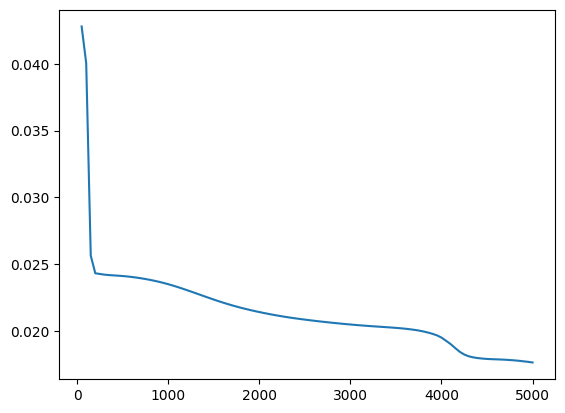

In [ ]:
plt.plot(df_rmse['Epoch'], df_rmse['RMSE'])
plt.show()
df_rmse.to_csv('MLP.csv', index=False)

In [ ]:
just_fourier = df_rmse['RMSE']

In [ ]:
spatio_fourier = df_rmse['RMSE']

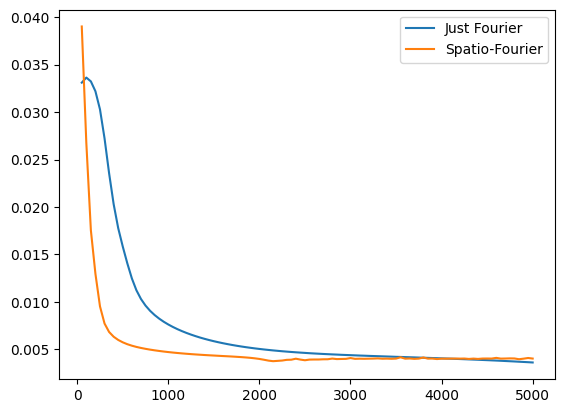

In [ ]:
plt.plot(df_rmse['Epoch'], just_fourier, label='Just Fourier')
plt.plot(df_rmse['Epoch'], spatio_fourier, label='Spatio-Fourier')
plt.legend()
plt.show()

In [ ]:
# model.compile("adam", lr=0.001)

# Обучение
losshistory, train_state = model.train(iterations=100, display_every=1)

Training model...

Step      Train loss                        Test loss                         Test metric
500       [1.60e-04, 1.98e-05, 8.10e-05]    [1.60e-04, 1.98e-05, 8.10e-05]    []  
501       [1.59e-04, 1.96e-05, 8.07e-05]    [1.59e-04, 1.96e-05, 8.07e-05]    []  
502       [1.59e-04, 1.94e-05, 8.03e-05]    [1.59e-04, 1.94e-05, 8.03e-05]    []  
503       [1.59e-04, 1.92e-05, 8.00e-05]    [1.59e-04, 1.92e-05, 8.00e-05]    []  
504       [1.58e-04, 1.91e-05, 7.97e-05]    [1.58e-04, 1.91e-05, 7.97e-05]    []  
505       [1.58e-04, 1.89e-05, 7.94e-05]    [1.58e-04, 1.89e-05, 7.94e-05]    []  
506       [1.58e-04, 1.87e-05, 7.91e-05]    [1.58e-04, 1.87e-05, 7.91e-05]    []  
507       [1.57e-04, 1.86e-05, 7.88e-05]    [1.57e-04, 1.86e-05, 7.88e-05]    []  
508       [1.57e-04, 1.84e-05, 7.84e-05]    [1.57e-04, 1.84e-05, 7.84e-05]    []  
509       [1.57e-04, 1.82e-05, 7.82e-05]    [1.57e-04, 1.82e-05, 7.82e-05]    []  
510       [1.56e-04, 1.81e-05, 7.79e-05]    [1.56e-04, 1.81e-

In [ ]:
# Сохранение весов сети
# model.save("my_model")

/tmp/ipykernel_1338/1330114113.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


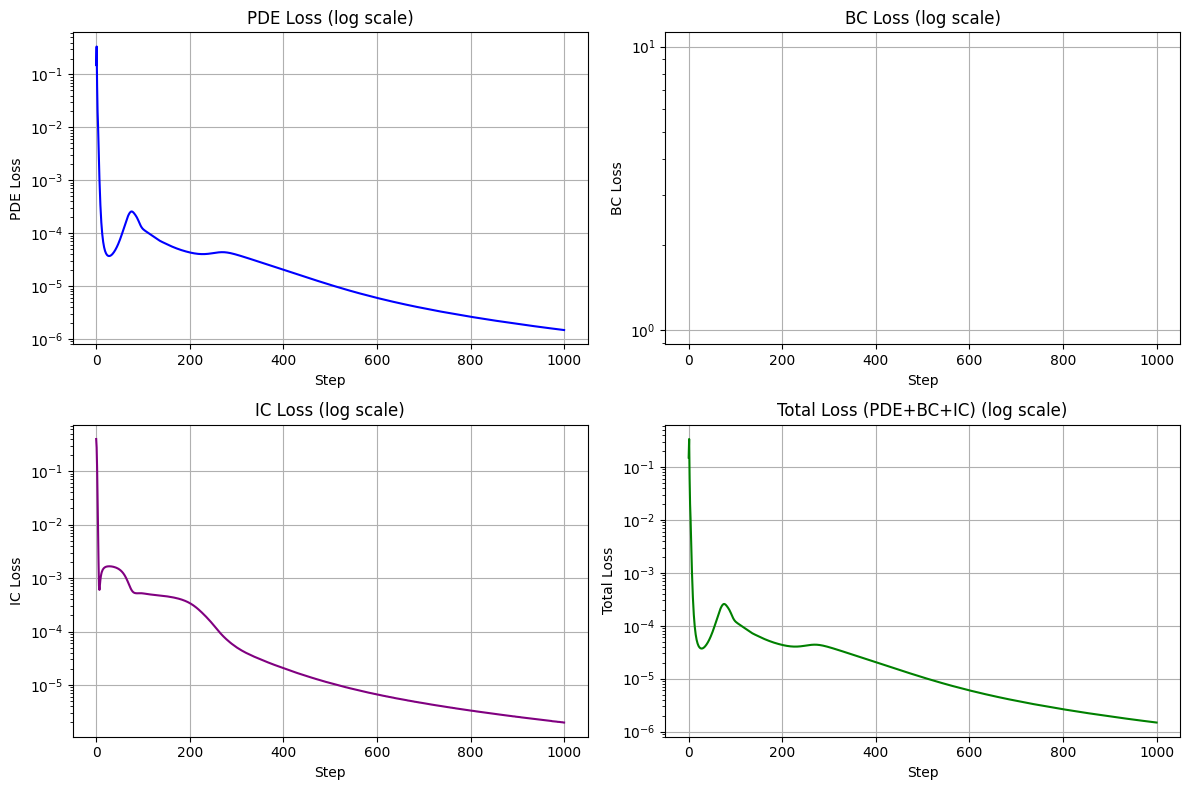

In [ ]:
# Извлекаем компоненты потерь (предполагается, что в losshistory.loss_train каждый элемент содержит [pde, bc, data_bc])
pde_losses = [arr[0] for arr in losshistory.loss_train]
bc_losses = [arr[1] for arr in losshistory.loss_train]
data_losses = [arr[2] for arr in losshistory.loss_train]

# Вычисляем общий loss (сумма PDE + BC + Data_BC)
# total_losses = [p + b + d for p, b, d in zip(pde_losses, bc_losses, data_losses)]
total_losses = [p + b for p, b in zip(pde_losses, bc_losses)]

steps = list(range(len(pde_losses)))

# Создаём сетку 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# axes.flat — плоский список из 4-х объектов Axes
ax1, ax2, ax3, ax4 = axes.flat

# График PDE loss
ax1.plot(steps, pde_losses, color='b')
ax1.set_xlabel('Step')
ax1.set_ylabel('PDE Loss')
ax1.set_title('PDE Loss (log scale)')
ax1.set_yscale('log')
ax1.grid(True)

# График BC loss
ax2.plot(steps, bc_losses, color='r')
ax2.set_xlabel('Step')
ax2.set_ylabel('BC Loss')
ax2.set_title('BC Loss (log scale)')
ax2.set_yscale('log')
ax2.grid(True)

# График Data_BC loss
ax3.plot(steps, data_losses, color='purple')
ax3.set_xlabel('Step')
ax3.set_ylabel('IC Loss')
ax3.set_title('IC Loss (log scale)')
ax3.set_yscale('log')
ax3.grid(True)

# График общего loss (сумма)
ax4.plot(steps, total_losses, color='g')
ax4.set_xlabel('Step')
ax4.set_ylabel('Total Loss')
ax4.set_title('Total Loss (PDE+BC+IC) (log scale)')
ax4.set_yscale('log')
ax4.grid(True)

plt.tight_layout()
plt.show()

# Визуализация новая

In [ ]:
# Загружаем эталон
# Columns: 0=time, 1=T(z=0 mm), 2=T(z=1 mm), 3=T(z=3 mm) — all at beam centre x=0,y=0
ref = np.loadtxt('out_Tt.txt', usecols=(0, 1, 2, 3)) # usecols=(0, 1, 2, 3)
t_ref      = ref[:, 0]   # time [s]
T_ref_0mm  = ref[:, 1]   # T at z = 0 mm [K]
T_ref_1mm  = ref[:, 2]   # T at z = 1 mm [K]
T_ref_3mm  = ref[:, 3]   # T at z = 3 mm [K]

# Subsample to ~50 anchor points per depth
step = max(1, len(t_ref) // 50)
t_anchor = t_ref[::step]

def _make_anchor(z_m, T_col):
    """Build (X, T) anchor arrays for a sensor at depth z_m."""
    X = np.stack([np.zeros_like(t_anchor),
                  np.zeros_like(t_anchor),
                  np.full_like(t_anchor, z_m),
                  t_anchor], axis=-1)
    T = T_col[::step].reshape(-1, 1)
    return X, T

X_anchor_0mm, T_anchor_0mm = _make_anchor(0.000, T_ref_0mm)
X_anchor_1mm, T_anchor_1mm = _make_anchor(0.001, T_ref_1mm)
X_anchor_3mm, T_anchor_3mm = _make_anchor(0.003, T_ref_3mm)

# Keep for backward-compat with diagnostics / visualisation
X_anchor = X_anchor_1mm
T_anchor = T_anchor_1mm

print(f'Sensor anchors: {len(t_anchor)} pts × 3 depths = {3*len(t_anchor)} total')

Sensor anchors: 50 pts × 3 depths = 150 total


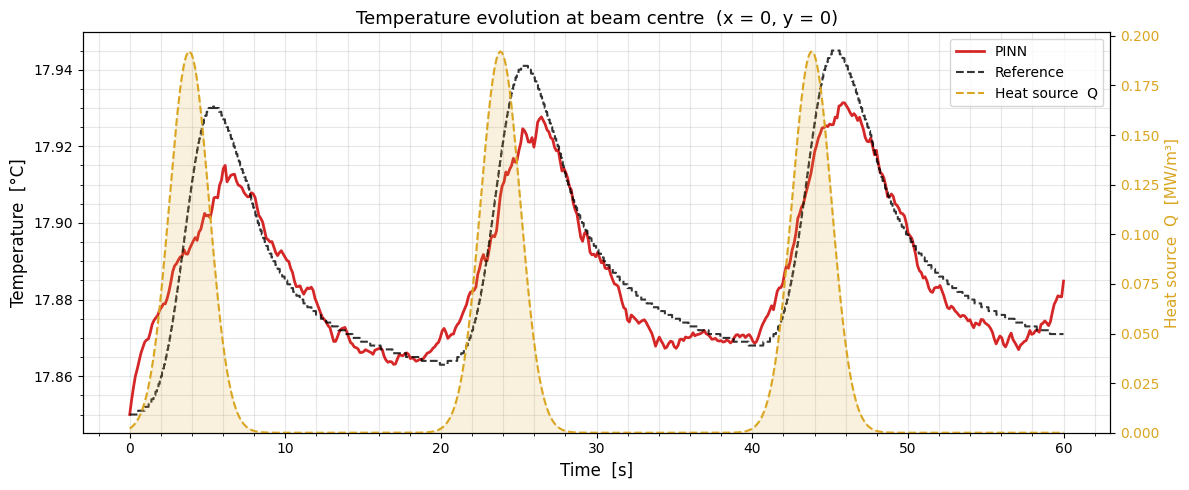

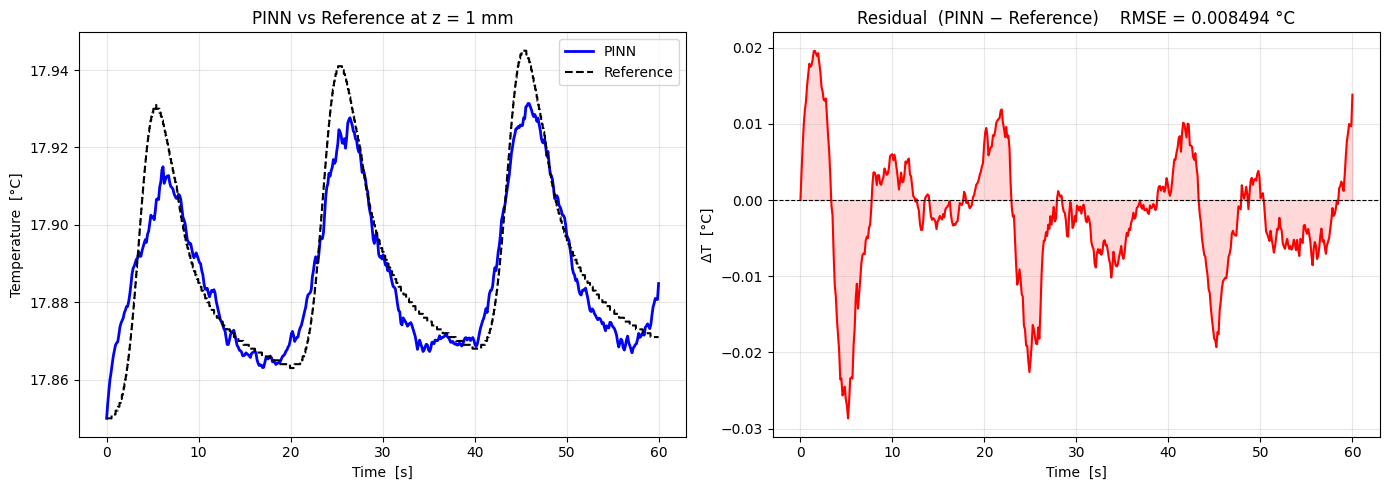

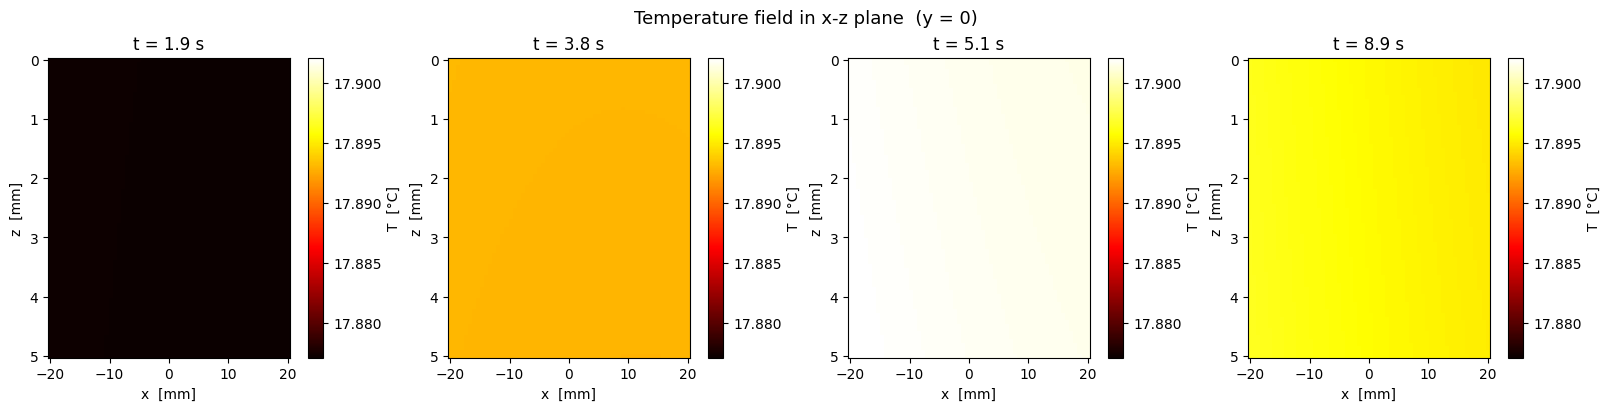

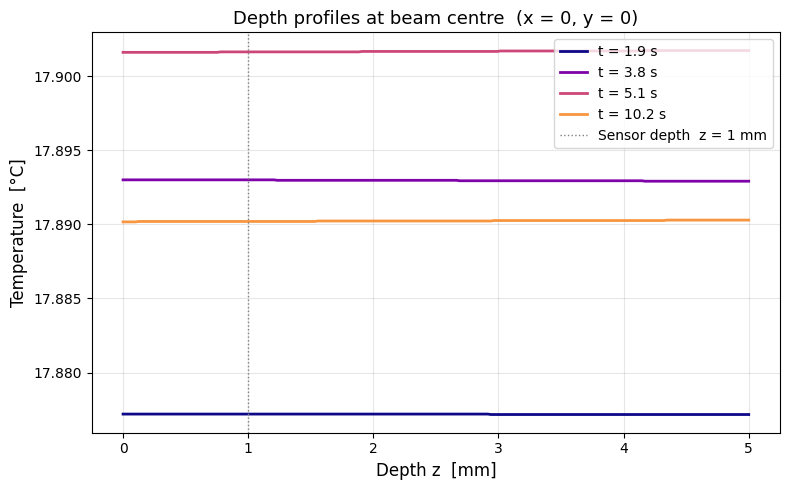

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Pre-compute all predictions needed for visualisation
# ─────────────────────────────────────────────────────────────────────────────

t_vals    = np.linspace(0, T_end, 500)
depths_m  = [1e-3]
depth_labels = ['z = 0 mm', 'z = 1 mm', 'z = 3 mm']
line_colors  = ['#d62728', '#ff7f0e', '#1f77b4']  # red, orange, blue

# -- T(t) at beam centre for each depth --------------------------------------
pts_temporal = np.array(
    [[0.0, 0.0, z, t] for z in depths_m for t in t_vals]
)
T_temporal_C = model.predict(pts_temporal).ravel() - 273.15
n = len(t_vals)
T_by_depth = {z: T_temporal_C[i*n:(i+1)*n] for i, z in enumerate(depths_m)}

# -- 2-D spatial grid in the x-z plane (y=0) --------------------------------
nx, nz     = 60, 80
x_1d       = np.linspace(-Lx/2, Lx/2, nx)
z_1d       = np.linspace(0, Lz, nz)
XX, ZZ     = np.meshgrid(x_1d, z_1d)          # shape (nz, nx)

t_snaps    = [t_peak / 2, t_peak,
              t_peak + pulse_sigma,
              t_peak + 4 * pulse_sigma]
snap_labels = [f't = {t:.1f} s' for t in t_snaps]

spatial_maps = []
for t_s in t_snaps:
    pts = np.column_stack([
        XX.ravel(), np.zeros(nx * nz),
        ZZ.ravel(), np.full(nx * nz, t_s)
    ])
    T_map = model.predict(pts).reshape(nz, nx) - 273.15
    spatial_maps.append(T_map)

# -- Depth profiles T(z) at beam centre at multiple times -------------------
z_vals          = np.linspace(0, Lz, 200)
t_profile_times = [t_peak / 2, t_peak,
                   t_peak + pulse_sigma,
                   t_peak + 5 * pulse_sigma]

depth_profiles = []
for t_s in t_profile_times:
    pts = np.column_stack([
        np.zeros(200), np.zeros(200),
        z_vals, np.full(200, t_s)
    ])
    depth_profiles.append(model.predict(pts).ravel() - 273.15)

# Heat source temporal profile at beam centre (x=0, y=0) and surface (z=0) – numpy only
# Q(0,0,0,t) = A * Q0 * alpha_absorption * sum_n exp(-(t-t_n)^2 / (2*sigma^2))
Q_surf_t = np.zeros_like(t_vals)
for _n in range(N_pulses):
    _t_n = t_peak + _n * pulse_period
    Q_surf_t += np.exp(-(t_vals - _t_n)**2 / (2 * pulse_sigma**2))
Q_surf_t *= A * Q0 * alpha_absorption   # W/m³

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1  –  T(t) at beam centre: PINN vs reference + sensor anchors
#              + heat source envelope on twin axis
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for z, label, color in zip(depths_m, depth_labels, line_colors):
    ax.plot(t_vals, T_by_depth[z], color=color, lw=2, label=f'PINN')

# Reference curve at z = 1 mm (column 1 of out_Tt.txt)
ax.plot(t_ref, T_ref_1mm - 273.15, 'k--', lw=1.5,
        alpha=0.8, label='Reference')

# Anchor (sensor) data points
# ax.scatter(t_anchor, T_anchor_1mm.ravel() - 273.15,
#            s=25, color='black', zorder=5, label='Sensor anchors')

ax.set_xlabel('Time  [s]', fontsize=12)
ax.set_ylabel('Temperature  [°C]', fontsize=12)
ax.set_title('Temperature evolution at beam centre  (x = 0, y = 0)', fontsize=13)
ax.minorticks_on()
ax.grid(which='both', alpha=0.3)

# Twin axis – heat source envelope
ax_q = ax.twinx()
ax_q.fill_between(t_vals, Q_surf_t * 1e-6, alpha=0.15, color='goldenrod')
ax_q.plot(t_vals, Q_surf_t * 1e-6, color='goldenrod', lw=1.5,
          ls='--', label='Heat source  Q')
ax_q.set_ylabel('Heat source  Q  [MW/m³]', fontsize=11, color='goldenrod')
ax_q.tick_params(axis='y', labelcolor='goldenrod')
ax_q.set_ylim(bottom=0)

# Merge legends from both axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_q.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=10)

plt.tight_layout()
plt.savefig('Tt_depths.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2  –  PINN vs Reference at z = 1 mm  +  residual
# ─────────────────────────────────────────────────────────────────────────────
T_pinn_1mm   = T_by_depth[1e-3]
T_ref_interp = np.interp(t_vals, t_ref, T_ref_1mm - 273.15)
residual     = T_pinn_1mm - T_ref_interp
rmse         = float(np.sqrt(np.mean(residual ** 2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t_vals, T_pinn_1mm, 'b-',  lw=2,   label='PINN')
ax1.plot(t_ref,  T_ref_1mm - 273.15, 'k--', lw=1.5, label='Reference')
# ax1.scatter(t_anchor, T_anchor_1mm.ravel() - 273.15,
#             s=30, color='red', zorder=5, label='Reference points (not used in training)')
ax1.set_xlabel('Time  [s]');  ax1.set_ylabel('Temperature  [°C]')
ax1.set_title('PINN vs Reference at z = 1 mm')
ax1.legend();  ax1.grid(alpha=0.3)

ax2.plot(t_vals, residual, 'r-', lw=1.5)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.fill_between(t_vals, residual, 0, alpha=0.15, color='red')
ax2.set_xlabel('Time  [s]');  ax2.set_ylabel('ΔT  [°C]')
ax2.set_title(f'Residual  (PINN − Reference)    RMSE = {rmse:.6f} °C')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Tt_comparison.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 3  –  2-D temperature maps in the x-z plane at key time snapshots
# ─────────────────────────────────────────────────────────────────────────────
vmin = min(m.min() for m in spatial_maps)
vmax = max(m.max() for m in spatial_maps)

fig, axes = plt.subplots(1, len(t_snaps), figsize=(16, 4),
                         constrained_layout=True)
for ax, T_map, label in zip(axes, spatial_maps, snap_labels):
    im = ax.pcolormesh(x_1d * 1e3, z_1d * 1e3, T_map,
                       cmap='hot', vmin=vmin, vmax=vmax, shading='auto')
    ax.set_xlabel('x  [mm]');  ax.set_ylabel('z  [mm]')
    ax.set_title(label)
    ax.invert_yaxis()          # surface (z = 0) at top
    plt.colorbar(im, ax=ax, label='T  [°C]')

fig.suptitle('Temperature field in x-z plane  (y = 0)', fontsize=13)
plt.savefig('T_xz_snapshots.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 4  –  Depth profiles T(z) at beam centre at multiple times
# ─────────────────────────────────────────────────────────────────────────────
cmap_p = plt.cm.plasma
fig, ax = plt.subplots(figsize=(8, 5))

for i, (t_s, T_z) in enumerate(zip(t_profile_times, depth_profiles)):
    ax.plot(z_vals * 1e3, T_z,
            color=cmap_p(i / len(t_profile_times)),
            lw=2, label=f't = {t_s:.1f} s')

# Mark the sensor depth (z = 1 mm)
ax.axvline(1.0, color='gray', ls=':', lw=1, label='Sensor depth  z = 1 mm')

ax.set_xlabel('Depth z  [mm]', fontsize=12)
ax.set_ylabel('Temperature  [°C]', fontsize=12)
ax.set_title('Depth profiles at beam centre  (x = 0, y = 0)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('T_depth_profiles.png', dpi=150)
plt.show()

# Визуализация старая

## Зависимость температуры от глубины z при фиксированных x=0,y=0,t=t_peak

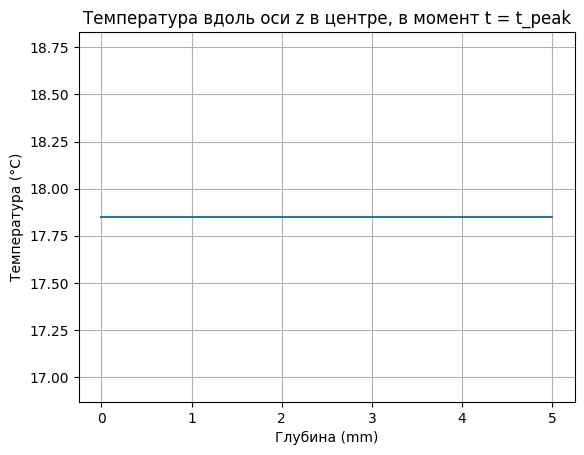

In [ ]:
z_test = np.linspace(0, 5e-3, 350)
points_z = np.array([[0.0, 0.0, z, t_peak] for z in z_test])
T_z = model.predict(points_z).flatten()
plt.figure()
plt.plot(z_test*1000, T_z-273.15) # z_test умножается на 1000, потому что ось x в миллиметрах, а не в метрах
plt.xlabel('Глубина (mm)')
plt.ylabel('Температура (°C)')
plt.title('Температура вдоль оси z в центре, в момент t = t_peak')
plt.grid()
plt.show()

## Построение графиков T(t) для трёх глубин (0, 1, 3 мм)

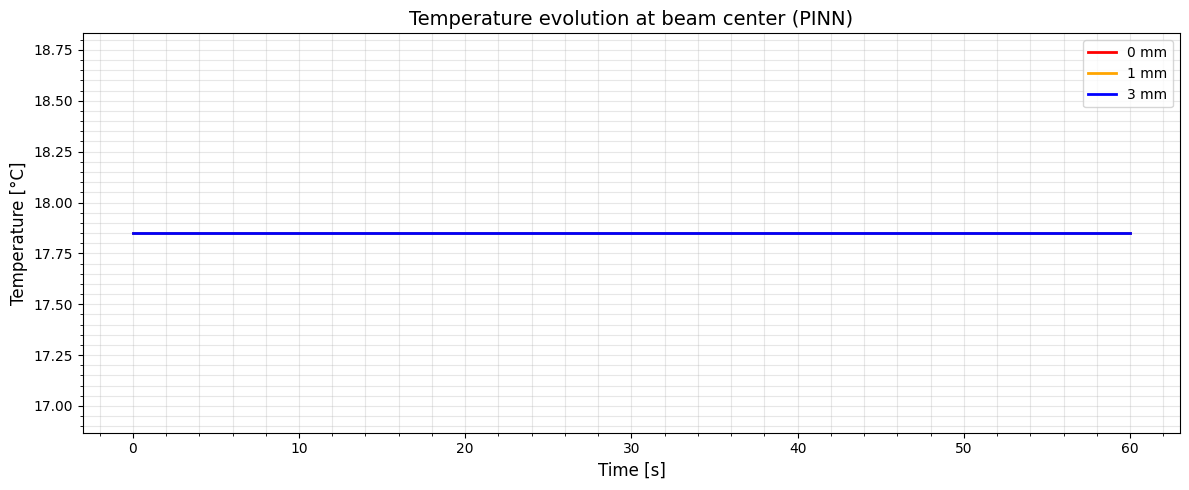

In [ ]:
# Временная сетка
t_vals = np.linspace(0, T_end, 1000)

# Глубины в метрах
depths_m = [0.0, 1e-3, 3e-3]
depth_labels = ['0 mm', '1 mm', '3 mm']
colors = ['red', 'orange', 'blue']

# Координаты точек: x=0, y=0, z=depth, t
points = []
for z in depths_m:
    for t in t_vals:
        points.append([0.0, 0.0, z, t])
points = np.array(points)

# Предсказание температуры
T_pred = model.predict(points)

# Преобразование в °C
T_pred_C = T_pred - 273.15

# Разделяем по глубинам
idx = 0
T_by_depth = []
for z in depths_m:
    n_pts = len(t_vals)
    T_by_depth.append(T_pred_C[idx:idx+n_pts])
    idx += n_pts

# Построение графиков
plt.figure(figsize=(12, 5))
for i, (z, T_z, color) in enumerate(zip(depths_m, T_by_depth, colors)):
    plt.plot(t_vals, T_z, color=color, linewidth=2, label=depth_labels[i])

plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Temperature [°C]', fontsize=12)
plt.title('Temperature evolution at beam center (PINN)', fontsize=14)
plt.minorticks_on()                     # включаем частые деления
plt.grid(which='both', alpha=0.3)       # сетка по всем делениям
plt.legend()
plt.tight_layout()
# plt.savefig('Tt_PINN.png', dpi=150)
plt.show()

## Сравнение с классическим решением (надо предварительно загрузить файл out_Tt.txt.)

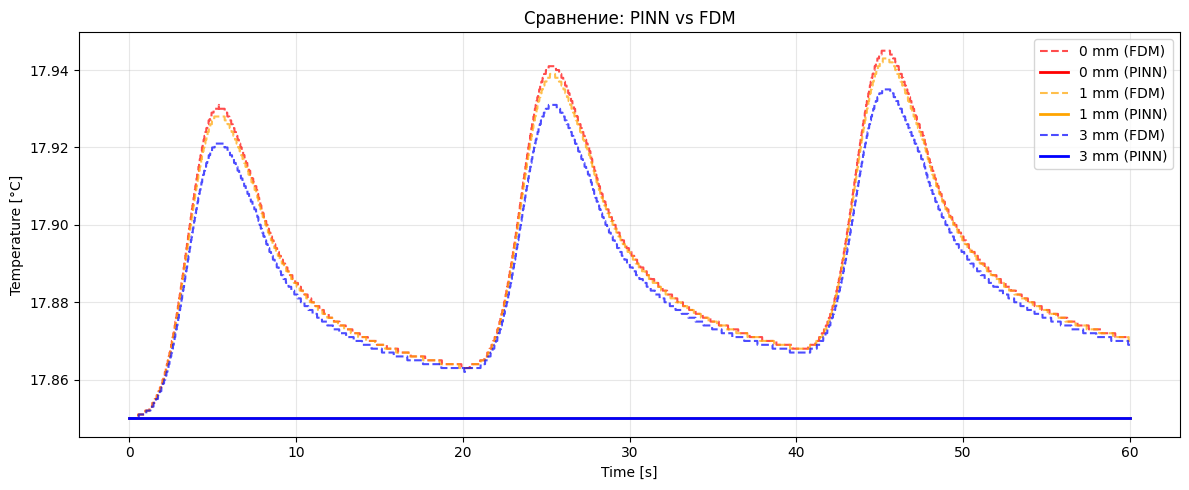

Done.


In [ ]:
try:
    # Загрузка численных данных out_Tt.txt
    data_num = np.loadtxt('out_Tt.txt', usecols=(0,1, 2, 3)) # usecols=(0,1, 2, 3)) ; delimiter=None
    t_num = data_num[:, 0]
    T0_num = data_num[:, 1] - 273.15
    T1_num = data_num[:, 2] - 273.15
    T3_num = data_num[:, 3] - 273.15

    plt.figure(figsize=(12, 5))

    # Точки которые использовались при обучении сети
    # plt.scatter(X_anchor[:, -1], T_anchor - 273.15)

    plt.plot(t_num, T0_num, 'r--', alpha=0.7, label='0 mm (FDM)')
    plt.plot(t_vals, T_by_depth[0], 'r-', linewidth=2, label='0 mm (PINN)')
    plt.plot(t_num, T1_num, 'orange', linestyle='--', alpha=0.7, label='1 mm (FDM)')
    plt.plot(t_vals, T_by_depth[1], 'orange', linewidth=2, label='1 mm (PINN)')
    plt.plot(t_num, T3_num, 'b--', alpha=0.7, label='3 mm (FDM)')
    plt.plot(t_vals, T_by_depth[2], 'b-', linewidth=2, label='3 mm (PINN)')
    plt.xlabel('Time [s]')
    plt.ylabel('Temperature [°C]')
    plt.title('Сравнение: PINN vs FDM')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    # plt.savefig('comparison_Tt.png', dpi=150)
    plt.show()
except FileNotFoundError:
    print("File out_Tt.txt not found, skipping comparison.")

print("Done.")

In [ ]:
T_by_depth[0].shape

(1000, 1)

In [ ]:
T0_num.shape

(115287,)

In [ ]:
t_num

array([5.00000e-04, 1.00000e-03, 1.50000e-03, ..., 5.76425e+01,
       5.76430e+01, 5.76435e+01])

# Эксперименты

## Зависимость от количества точек коллокации

In [ ]:
result = pd.DataFrame(columns=['количество точек коллокации', 'MSE'])

coll_points = np.hstack((np.arange(10, 100, step=10),
              np.arange(100, 1_000, step=100),
              np.arange(1_000, 10_000, step=1000),
              np.arange(10_000, 60_000, step=10_000)
              )).tolist()


data_num = np.loadtxt('out_Tt.txt', usecols=(0, 1, 2, 3)) # usecols=(0, 1, 2, 3)) ; delimiter=None
t_num = data_num[:, 0]
T0_num = data_num[:, 1] - 273.15
T1_num = data_num[:, 2] - 273.15
T3_num = data_num[:, 3] - 273.15

# Глубины в метрах
depths_m = [0.0] # [0.0, 1e-3, 3e-3]

# Координаты точек: x=0, y=0, z=depth, t
points = []
for z in depths_m:
    for t in t_num:
        points.append([0.0, 0.0, z, t])
points = np.array(points)


for num_points in coll_points:
  print(f'num_points = {num_points}')
  data = dde.data.TimePDE(
      geomtime,
      pde,
      [bc], # data_bc
      num_domain=int(num_points),
      num_boundary=int(num_points)
      )


  # Определение сети
  net = dde.nn.FNN(
      layer_sizes = [4] + [100] * 5 + [1],
      activation = "tanh",
      kernel_initializer = "Glorot normal",
      )

  # Hard constraint для начального условия
  def output_transform(x, y):
      t = x[:, 3:4]
      return 291.0 + t * y
  net.apply_output_transform(output_transform)

  # Модель
  model = dde.Model(data, net)

  model.compile("adam", lr=0.001)


  # Обучение
  losshistory, train_state = model.train(iterations=2000, display_every=100)


  # Предсказание температуры
  T_pred = model.predict(points)

  # Преобразование в °C
  T_pred_C = T_pred - 273.15

  mse = (((T_pred_C).squeeze() - T0_num) ** 2).mean()
  result.loc[len(result)] = [num_points, mse]

In [ ]:
result['количество точек коллокации'] = result['количество точек коллокации'] * 2 # общее количество = num_boundary * 2

In [ ]:
result.to_csv('result.csv', index=False)  # index=False — не записывать индексы строк

In [ ]:
result = pd.read_csv('result.csv')

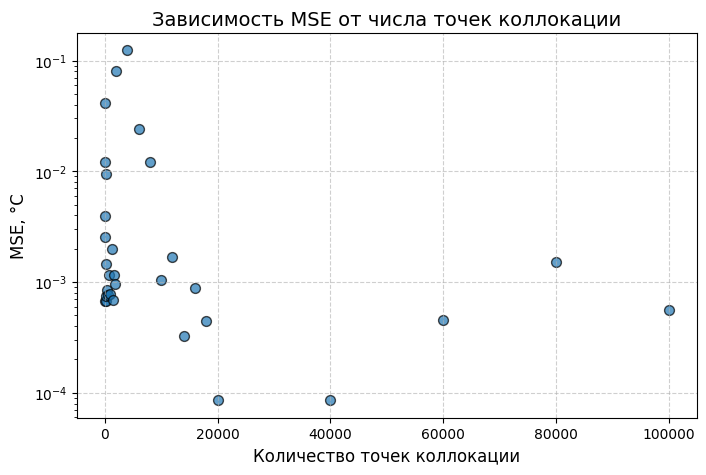

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(result['количество точек коллокации'], result['MSE'], alpha=0.7, edgecolors='k', s=50)
plt.xlabel('Количество точек коллокации', fontsize=12)
plt.ylabel('MSE, °C', fontsize=12)
plt.title('Зависимость MSE от числа точек коллокации', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log')  # логарифмическая шкала по Y
# или plt.xscale('log') и plt.yscale('log') если нужно
plt.savefig('mse_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Зависимость от количества нейронов и слоев

In [ ]:
result = pd.DataFrame(columns=['количество слоев', 'количество нейронов', 'MSE'])

layers = [1, 2, 3, 4, 5, 6, 7, 8]
neurons = [25, 50, 75, 100, 150, 200]


data_num = np.loadtxt('out_Tt.txt', usecols=(0, 1, 2, 3)) # usecols=(0, 1, 2, 3)) ; delimiter=None
t_num = data_num[:, 0]
T0_num = data_num[:, 1] - 273.15
T1_num = data_num[:, 2] - 273.15
T3_num = data_num[:, 3] - 273.15

# Глубины в метрах
depths_m = [0.0] # [0.0, 1e-3, 3e-3]

# Координаты точек: x=0, y=0, z=depth, t
points = []
for z in depths_m:
    for t in t_num:
        points.append([0.0, 0.0, z, t])
points = np.array(points)


for l in layers:
  for n in neurons:
    print(f'layers = {l}, neurons = {n}')

    # Определение сети
    net = dde.nn.FNN(
        layer_sizes = [4] + [n] * l + [1],
        activation = "tanh",
        kernel_initializer = "Glorot normal",
        )

    # Hard constraint для начального условия
    def output_transform(x, y):
        t = x[:, 3:4]
        return 291.0 + t * y
    net.apply_output_transform(output_transform)

    # Модель
    model = dde.Model(data, net)

    model.compile("adam", lr=0.001)


    # Обучение
    losshistory, train_state = model.train(iterations=2000, display_every=100)


    # Предсказание температуры
    T_pred = model.predict(points)

    # Преобразование в °C
    T_pred_C = T_pred - 273.15

    mse = (((T_pred_C).squeeze() - T0_num) ** 2).mean()
    result.loc[len(result)] = [l, n, mse]

layers = 1, neurons = 25
Compiling model...
Building feed-forward neural network...
'build' took 0.032966 s

'compile' took 0.538403 s

Training model...

Step      Train loss              Test loss               Test metric
0         [2.57e-01, 1.36e+01]    [2.57e-01, 1.36e+01]    []  
100       [2.66e-03, 3.88e-01]    [2.66e-03, 3.88e-01]    []  
200       [2.96e-03, 7.63e-02]    [2.96e-03, 7.63e-02]    []  
300       [1.11e-03, 8.97e-03]    [1.11e-03, 8.97e-03]    []  
400       [2.25e-04, 3.45e-03]    [2.25e-04, 3.45e-03]    []  
500       [1.70e-04, 1.71e-03]    [1.70e-04, 1.71e-03]    []  
600       [1.92e-04, 9.09e-04]    [1.92e-04, 9.09e-04]    []  
700       [1.84e-04, 5.40e-04]    [1.84e-04, 5.40e-04]    []  
800       [1.61e-04, 3.55e-04]    [1.61e-04, 3.55e-04]    []  
900       [1.33e-04, 2.48e-04]    [1.33e-04, 2.48e-04]    []  
1000      [1.07e-04, 1.83e-04]    [1.07e-04, 1.83e-04]    []  
1100      [8.35e-05, 1.41e-04]    [8.35e-05, 1.41e-04]    []  
1200      [6.35e-05

In [ ]:
result.to_csv('result.csv', index=False)

In [ ]:
result.iloc[29]['MSE'] = (0.000832 + 0.000790) / 2

/tmp/ipykernel_5490/2154587476.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result.iloc[29]['MSE'] = (0.000832 + 0.000790) / 2


In [ ]:
result

,количество слоев,количество нейронов,MSE
0,1.0,25.0,0.000111
1,1.0,50.0,0.000255
2,1.0,75.0,0.001111
3,1.0,100.0,0.000688
4,1.0,150.0,0.000680
5,1.0,200.0,0.000796
6,2.0,25.0,0.003282
7,2.0,50.0,0.000933
8,2.0,75.0,0.000809
9,2.0,100.0,0.000641


In [ ]:
import seaborn as sns

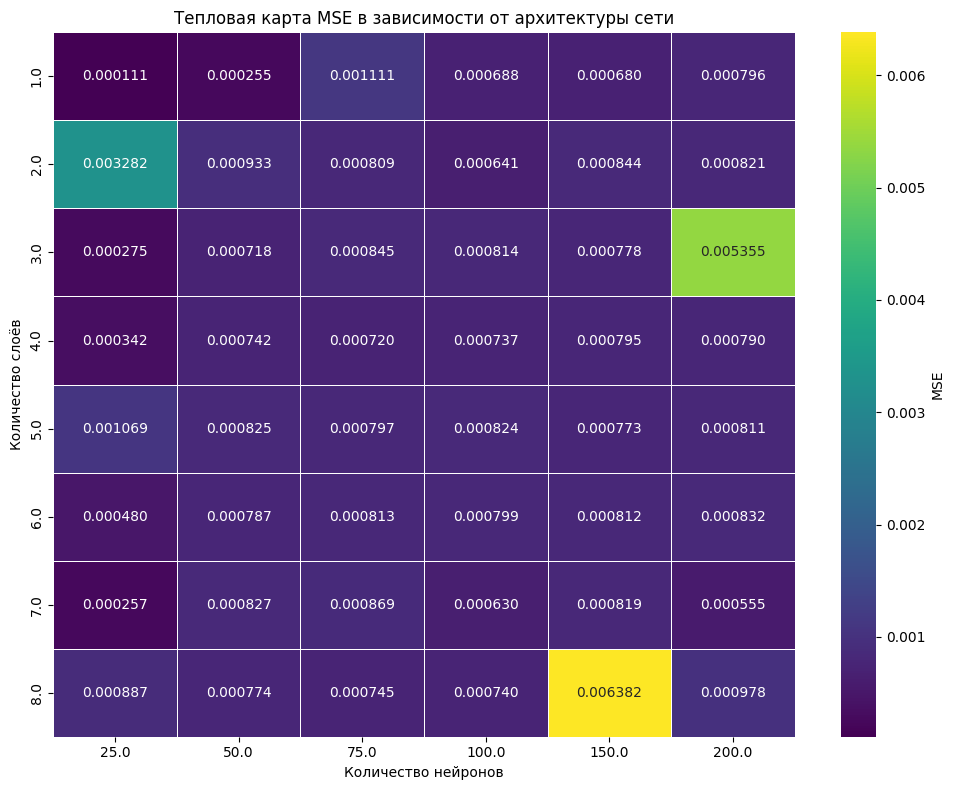

In [ ]:
# Создаём сводную таблицу: строки = количество слоёв, столбцы = количество нейронов, значения = MSE
heatmap_data = result.pivot(index='количество слоев',
                            columns='количество нейронов',
                            values='MSE')

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data,
            annot=True,          # показывать числа в ячейках
            fmt='.6f',           # формат чисел (3 знака после запятой)
            cmap='viridis',      # цветовая схема (можно 'coolwarm', 'plasma', 'RdYlGn_r')
            linewidths=0.5,      # линии между ячейками
            cbar_kws={'label': 'MSE'})

plt.xlabel('Количество нейронов')
plt.ylabel('Количество слоёв')
plt.title('Тепловая карта MSE в зависимости от архитектуры сети')
plt.tight_layout()
plt.savefig('heatmap_mse.png', dpi=300, bbox_inches='tight')
plt.show()

## Сходимость для разных архитектур

In [ ]:
# Assume model, T_end, t_ref, T_ref_1mm are already defined
# (from the preceding code in the user's script)

total_epochs = 0
epochs_per_block = 50
target_epochs = 5_000
results = []

# Use same temporal grid as in the original visualisation
t_vals_rmse = np.linspace(0, T_end, 500)

while total_epochs < target_epochs:
    # Train for 50 iterations (epochs)
    model.train(iterations=epochs_per_block, display_every=1)
    total_epochs += epochs_per_block

    # Compute PINN prediction at z = 1 mm (beam centre)
    pts = np.array([[0.0, 0.0, 1e-3, t] for t in t_vals_rmse])
    T_pinn = model.predict(pts).ravel() - 273.15

    # Interpolate reference data to the same time grid
    T_ref_interp = np.interp(t_vals_rmse, t_ref, T_ref_1mm - 273.15)

    # RMSE
    residual = T_pinn - T_ref_interp
    rmse = float(np.sqrt(np.mean(residual ** 2)))

    results.append([total_epochs, rmse])

# Save results in a pandas DataFrame
df_rmse = pd.DataFrame(results, columns=['Epoch', 'RMSE'])
print(df_rmse)